# Kinematics Explorer

In [2]:
import csv
import matplotlib.pyplot as plt
from plate_tracker.kinematics import compute_metrics, compute_timeseries

## Load centroids
Load `('cx', 'cy')` pairs from a CSV.

In [3]:
with open("../data/output/centroids.csv", "r") as f:
    reader = csv.DictReader(f)
    centroids = [(float(row["cx"]), float(row["cy"])) for row in reader]

In [4]:
FPS = 30.0
SCALE = 0.450 / 100  # example: plate was ~100px wide in the video
MASS_KG = 170.0  # set to None to skip force/power

## Bar path (x vs y)

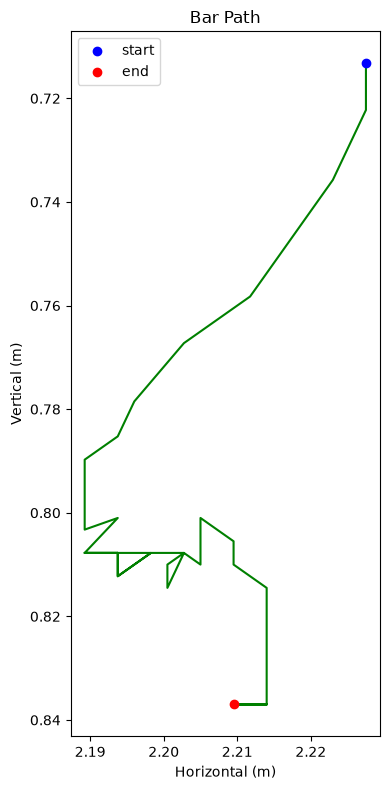

In [5]:
if centroids:
    xs = [cx * SCALE for cx, _ in centroids]
    ys = [cy * SCALE for _, cy in centroids]

    plt.figure(figsize=(4, 8))
    plt.plot(xs, ys, color='green', linewidth=1.5)
    plt.scatter(xs[0], ys[0], color='blue', label='start', zorder=5)
    plt.scatter(xs[-1], ys[-1], color='red', label='end', zorder=5)
    plt.gca().invert_yaxis()  # screen coords: y increases downward
    plt.xlabel('Horizontal (m)')
    plt.ylabel('Vertical (m)')
    plt.title('Bar Path')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Velocity and acceleration over time

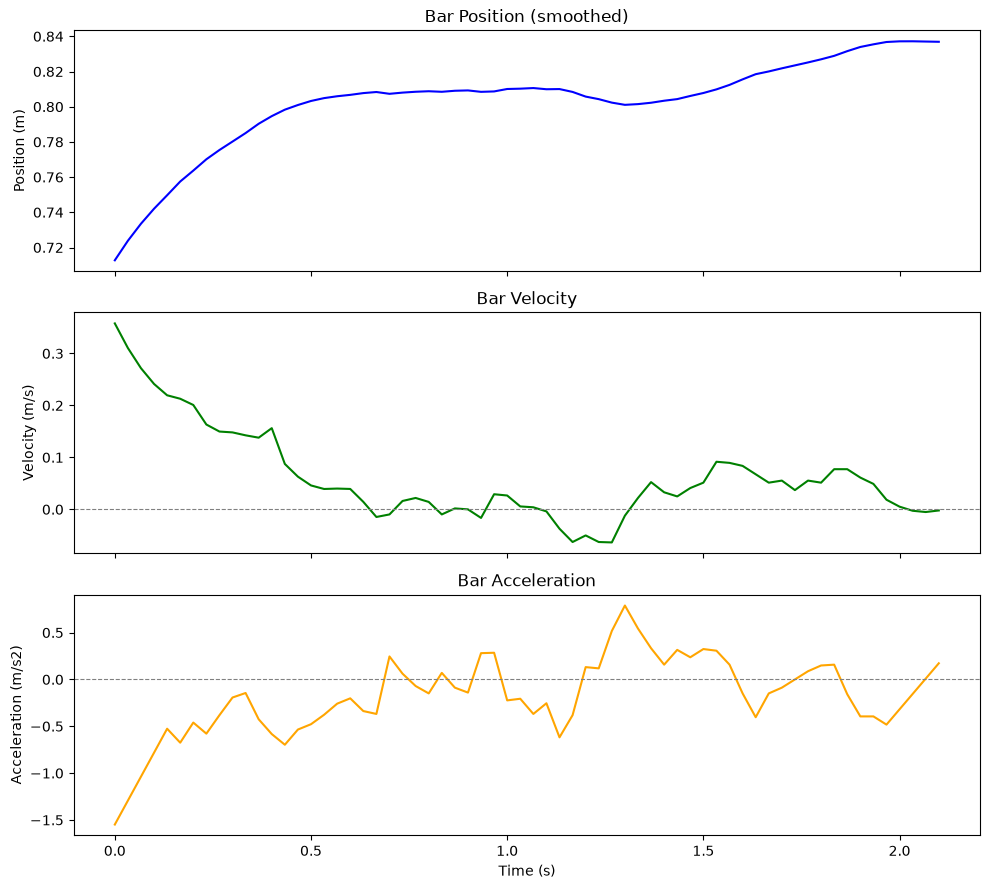

In [6]:
ts = compute_timeseries(centroids, FPS, SCALE)

if ts:
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    axes[0].plot(ts['t'], ts['position'], color='blue')
    axes[0].set_ylabel('Position (m)')
    axes[0].set_title('Bar Position (smoothed)')

    axes[1].plot(ts['t'], ts['velocity'], color='green')
    axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[1].set_ylabel('Velocity (m/s)')
    axes[1].set_title('Bar Velocity')

    axes[2].plot(ts['t'], ts['acceleration'], color='orange')
    axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[2].set_ylabel('Acceleration (m/s2)')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_title('Bar Acceleration')

    plt.tight_layout()
    plt.show()

## Summary metrics

In [7]:
metrics = compute_metrics(centroids, FPS, SCALE, MASS_KG)
for key, value in metrics.items():
    print(f"{key}: {value}")

velocity_m_s: -0.013
acceleration_m_s2: -0.124
peak_velocity_m_s: 0.341
mean_velocity_m_s: 0.07
force_n: 1646.66
power_w: 21.28
